# Simple back projections

In [10]:
import os
import numpy as np
import pandas as pd
import joblib
import json
import nibabel as nib


# Path to saved task folder
task = "risksensitive"
task_dir = f"/mnt/scratch/projects/rewardMap/reward_signature/final_model/{task}"

# 1️⃣ Load NPZ data
npz_file = os.path.join(task_dir, "data.npz")
data = np.load(npz_file, allow_pickle=True)

X = data["X"]
Y = data["Y"]
Y_signed = data["Y_signed"]
trial_types = data["trial_types"]
index_ranges = data["index_ranges"]
train_splits = data["train_splits"].tolist()  # convert from object array to list
val_splits = data["val_splits"].tolist()
split_ids = data["split_ids"]

print("Loaded data.npz successfully!")
print(f"X shape: {X.shape}, Y shape: {Y.shape}")

# 2️⃣ Load trained model
best_model = joblib.load(os.path.join(task_dir, "best_model.joblib"))
print("Loaded best_model.joblib successfully!")

# 3️⃣ Load best score
with open(os.path.join(task_dir, "best_score.json"), "r") as f:
    best_score_data = json.load(f)
best_score = best_score_data["best_score"]
print(f"Best CV score: {best_score}")

# 4️⃣ Load CV results
cv_results = pd.read_csv(os.path.join(task_dir, "cv_results.csv"))
print(f"CV results loaded: {cv_results.shape}")

print(best_model)

Loaded data.npz successfully!
X shape: (2645, 232910), Y shape: (2645,)
Loaded best_model.joblib successfully!
Best CV score: 0.579578558611491
CV results loaded: (50, 35)
Pipeline(steps=[('scaler', StandardScaler()),
                ('correlate', CorrelateTransformer(keep_ratio=0.4)),
                ('pca', PCA(n_components=75)),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=10000,
                                    solver='saga'))])


Selected idx: (93164,)
weights_original shape: (1, 93164)


/mnt/projects/rewardMap/STUDIES/reward_signature/.venv/lib64/python3.9/site-packages/numpy/_core/fromnumeric.py:820: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



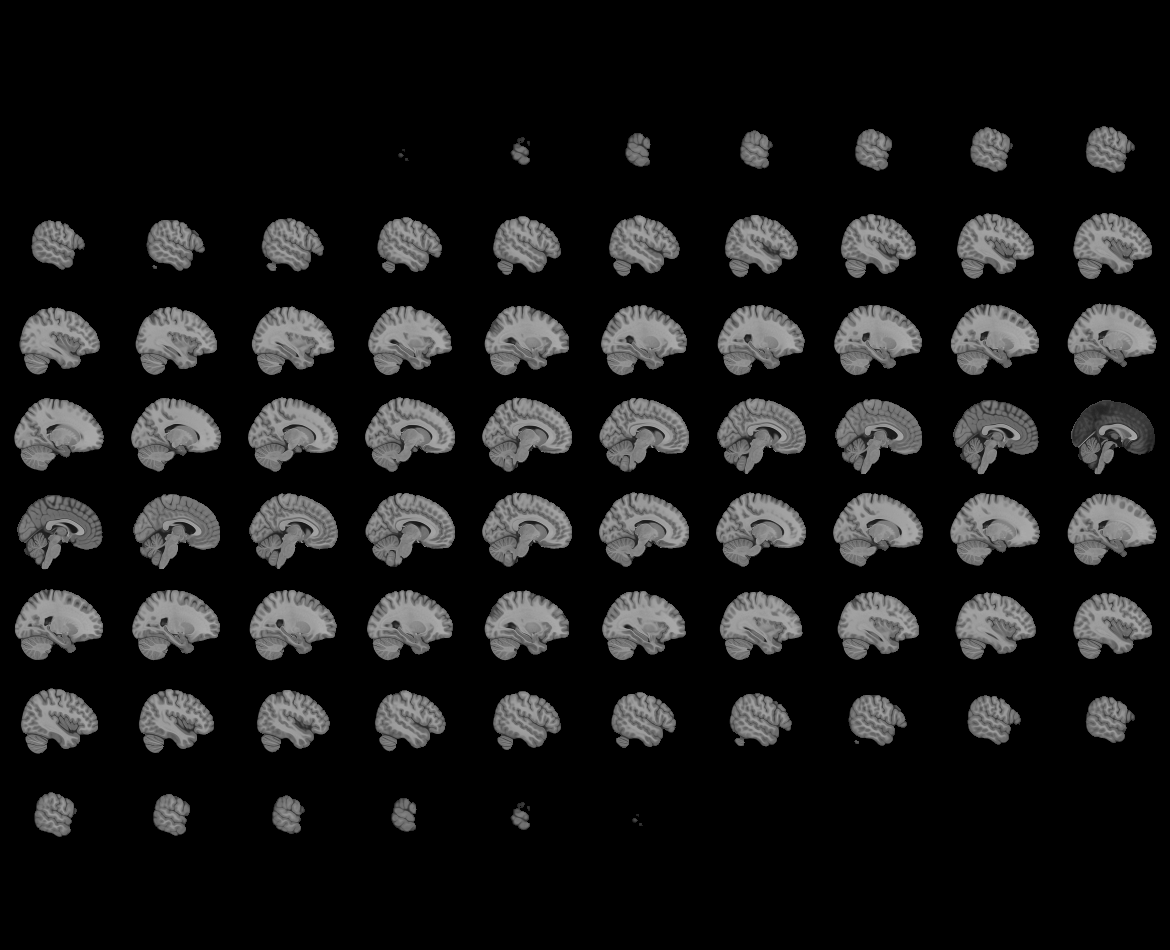
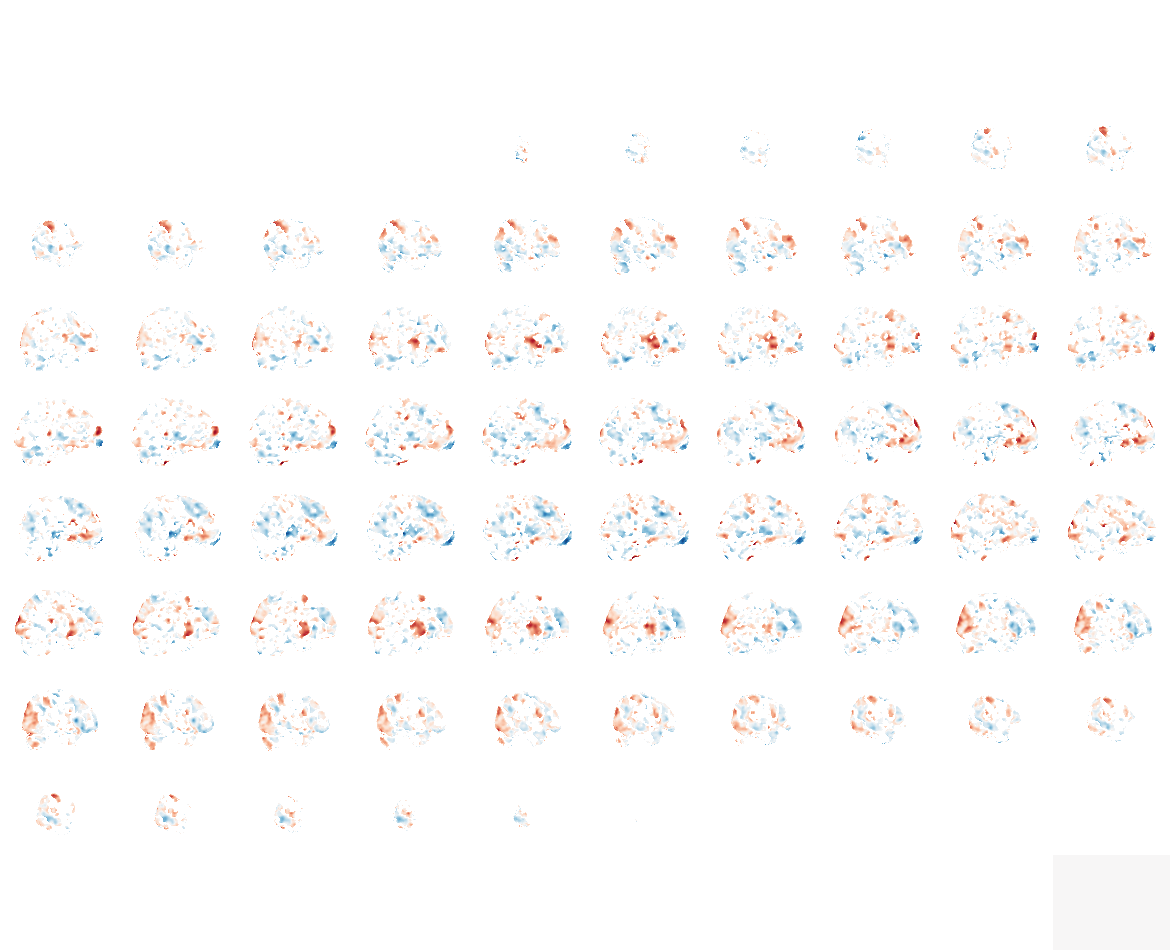

In [11]:
def cut_mask(in_file):
    nii = nib.load(in_file)
    data = nii.get_fdata()
    affine = nii.affine
    header = nii.header
    trimmed = data[:, :, 12:]    # drop slices 0–11
    trimmed = np.concatenate((np.zeros_like(data[:, :, :12]), trimmed), axis=2)  # just to show original vs trimmed
    trimmed_nii = nib.Nifti1Image(trimmed, affine, header)

    return trimmed_nii

brain_mask_path = "/mnt/projects/rewardMap/STUDIES/pilotstudy/derivatives/masks/tpl-MNI152NLin2009cAsym_res-02_desc-brain_mask.nii.gz"

mask = cut_mask(brain_mask_path)

import numpy as np
from nilearn.masking import unmask

brain_mask_path = "/mnt/projects/rewardMap/STUDIES/pilotstudy/derivatives/masks/tpl-MNI152NLin2009cAsym_res-02_desc-brain_mask.nii.gz"

pca = best_model["pca"]
model = best_model["model"]

# Transform PCA-space weights back to masked space
weights_pc = model.coef_
weights_original = pca.inverse_transform(weights_pc)

selected_idx = best_model["correlate"].selected_idx_
print("Selected idx:", selected_idx.shape)
print("weights_original shape:", weights_original.shape)


mask_data = mask.get_fdata().astype(bool)
n_voxels = mask_data.sum()

assert weights_original.shape[1] == len(selected_idx), \
       "Mismatch: weights_original must match number of selected voxels."

# average across classes if multi-class
weights_original = np.mean(weights_original, axis=0)
full_weights = np.zeros(n_voxels)
full_weights[selected_idx] = weights_original

# Now unmask back to 3D
weight_map_img = unmask(full_weights, mask)


from nilearn.plotting import view_img
view_img(weight_map_img, title="Model Weights in Original Space")


# Bootstrap

In [ ]:
import os
import numpy as np

from nilearn.masking import unmask
from nilearn.plotting import view_img
from scipy.stats import ttest_1samp
from statsmodels.sandbox.stats.multicomp import multipletests

STATISTIC = 'CI' #t-stat, CI
ALPHA = 0.05
output_html = f"/mnt/projects/rewardMap/STUDIES/reward_signature/reports/bootstrap_{STATISTIC}.html"


brain_mask_path = "/mnt/projects/rewardMap/STUDIES/pilotstudy/derivatives/masks/tpl-MNI152NLin2009cAsym_res-02_desc-brain_mask.nii.gz"

tasks = ['mid', 'gonogo', 'hcp', 'risksensitive', 'twostep']

def load_weights(task):
    task_dir = f"/mnt/scratch/projects/rewardMap/reward_signature/final_model/{task}"

    array = []

    for i in range(10):
        f_name = os.path.join(task_dir, f"bootstrap_weights_idx{i:02d}.npy")
        array.append(np.load(f_name))

    weights = np.vstack(array)

    if task == 'risksensitive' or task == 'twostep':
        return np.squeeze(weights)

    weights_1 = np.squeeze(weights[:,::3,:])
    weights_2 = np.squeeze(weights[:,1::3,:])
    weights_3 = np.squeeze(weights[:,2::3,:])

    return weights_1, weights_2, weights_3

def load_model_data(task):
    task_dir = f"/mnt/scratch/projects/rewardMap/reward_signature/final_model/{task}"
    model = joblib.load(os.path.join(task_dir, "best_model.joblib"))

    classes = model["model"].classes_
    corr = model["correlate"].keep_ratio

    return classes, corr


def significance_map(weights):
    mask = cut_mask(brain_mask_path)

    if STATISTIC == 'CI':
        median_weights = np.median(weights, axis=0)

        lower_ci = np.percentile(weights, (0 + ALPHA/2)*100, axis=0)
        upper_ci = np.percentile(weights, (1 - ALPHA/2)*100, axis=0)

        significant = (lower_ci > 0) | (upper_ci < 0)
        filtered_median = np.where(significant, median_weights, 0)

    elif STATISTIC == 't-stat':
        res = ttest_1samp(weights, popmean=0, axis=0, alternative='two-sided')
        p_values = res.pvalue.flatten()

        reject, p_corrected, _, _ = multipletests(p_values, alpha=ALPHA, method='fdr_bh')
    
        significant = reject.reshape(res.pvalue.shape)

    weight_map_img = unmask(significant, mask)
    return weight_map_img

def make_dict():
    weight_map_dict = {}
    model_dict = {}
    big_dic = {"weights": weight_map_dict, "model": model_dict}


    for task in tasks:
        classes, corr = load_model_data(task)
        model_dict[task] = (classes, corr)

        if task == 'risksensitive' or task == 'twostep':

            weights = load_weights(task)
            map = significance_map(weights)
            weight_map_dict[task] = [map]
        
        else:
            weights_1, weights_2, weights_3 = load_weights(task)
            map_1 = significance_map(weights_1)
            map_2 = significance_map(weights_2)
            map_3 = significance_map(weights_3)
            weight_map_dict[task] = [map_1, map_2, map_3]
        
    return big_dic



def save_to_html(big_dic):
    weight_map_dict = big_dic["weights"]
    model_dict = big_dic["model"]

    html = f"""
    <html>
    <head>
        <title>Weight maps 0.95 {STATISTIC}</title>
        <style>
            body {{ font-family: Arial, sans-serif; margin: 40px; }}
            h1 {{ color: #333; }}
            img {{ max-width: 700px; margin-bottom: 20px; }}
            iframe {{ width: 700px; height: 500px; border: none; margin-bottom: 20px; }}
        </style>
    </head>
    <body>
    """
    for task in weight_map_dict:
        snippet = f"""
                <h2>{task}, corr_cut: {model_dict[task][1]}</h2>
        """
        for i, weight_map in enumerate(weight_map_dict[task]):
            view = view_img(weight_map, title=f"Model Weights Class: {model_dict[task][0][i]}")
            weight_map_html = view._repr_html_()
            snippet += f"{weight_map_html}"
        
        html += snippet

    html += f"""
    </body>
    </html>
    """

    with open(output_html, "w") as f:
        f.write(html)

    print(f"HTML report saved to: {output_html}")


In [13]:
big_dic = make_dict()
save_to_html(big_dic)

TypeError: X must be of shape (samples, 232910).